In [1]:
HF_token = "hf_token"

In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [3]:
from datasets import load_dataset

dataset = load_dataset(path='mrdbourke/learn_hf_food_not_food_image_captions')

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [5]:
# what features we have
dataset.column_names

{'train': ['text', 'label']}

In [6]:
import random

random_indexes = random.sample(range(len(dataset['train'])), 5)

print(random_indexes)
random_samples = dataset['train'][random_indexes]
for text, label in zip(random_samples['text'], random_samples['label']):
    print(f'text: {text} | label: {label}')

[26, 88, 27, 210, 24]
text: Fresh cherry tomatoes in a basket, sprinkled with sea salt for a savory snack. | label: food
text: A bowl of sliced kiwi with a sprinkle of sugar and a side of yogurt | label: food
text: A whole pizza pie with a thin and crispy crust | label: food
text: A bowl of mixed berries, including blueberries, raspberries, and blackberries | label: food
text: Set of headphones placed on a desk | label: not_food


In [7]:
from collections import Counter

Counter(dataset['train']['label'])

Counter({'food': 125, 'not_food': 125})

In [8]:
import pandas as pd 

# turn our dataset into dataframe 
food_not_food_df = pd.DataFrame(dataset['train'])
food_not_food_df.sample(10)

,text,label
58,A boy building a fort in the living room with ...,not_food
34,Margherita pizza topped with fresh basil leave...,food
22,Nigiri sushi topped with fresh salmon and tuna...,food
225,"Spicy chickpea curry bowl, featuring nutty chi...",food
192,Set of spoons stored in a drawer,not_food
157,Vacuum cleaner stored in a closet,not_food
57,Vegetarian sushi roll with avocado and pickled...,food
133,"Comforting lentil dal curry, featuring nutty l...",food
221,Cherry tomatoes and mozzarella balls in a bowl...,food
14,"A slice of pizza with a pesto base, topped wit...",food


In [9]:
food_not_food_df['label'].value_counts()

label
food        125
not_food    125
Name: count, dtype: int64

In [10]:
# create mapping for our labels to numeric values 
id2label = {idx: text for idx, text in enumerate(dataset['train'].unique('label')[::-1])}
label2id = {text: idx for idx, text in id2label.items()}

In [11]:
label2id

{'not_food': 0, 'food': 1}

In [12]:
id2label

{0: 'not_food', 1: 'food'}

In [13]:
def map_label_to_number(example):
    example['label'] = label2id[example['label']]

    return example

In [14]:
example = {'text':'i like pizza', 'label':'food'}

map_label_to_number(example=example)

{'text': 'i like pizza', 'label': 1}

In [15]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [16]:
dataset = dataset['train'].map(map_label_to_number)

In [17]:
dataset[:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [18]:
# shuffle data and look at 5 more random srandom_samples
dataset.shuffle()[:5]

{'text': ['A bowl of sliced kiwi with a sprinkle of sugar and a side of yogurt',
  'A slice of pizza with a spicy buffalo chicken topping and a drizzle of ranch dressing',
  'Set of tools organized in a garage',
  'Set of potholders stored in a drawer',
  'A close-up of a family playing a board game with their pets watching intently'],
 'label': [1, 1, 0, 0, 0]}

In [19]:
# split the dataset in to train and test split
dataset = dataset.train_test_split(test_size=0.2, seed=42)

In [20]:
random_idx_train = random.randint(0, len(dataset['train']))
random_sample_train = dataset['train'][random_idx_train]
random_sample_train

{'text': 'A gourmet pizza with a pesto base, topped with grilled chicken and sun-dried tomatoes',
 'label': 1}

In [21]:
random_idx_test = random.randint(0, len(dataset['test']))
random_test_sample = dataset['test'][random_idx_test]
random_test_sample

{'text': 'Set of cookie cutters collected in a jar', 'label': 0}

In [22]:
# tokenization process
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path='distilbert/distilbert-base-uncased',
                                         use_fast=True)

In [23]:
tokenizer('i love pizza !!!')

{'input_ids': [101, 1045, 2293, 10733, 999, 999, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

In [24]:
# get the length of our tokenizer
length_of_tokenizer = len(tokenizer.vocab)
print(f'[INFO] vocab size:{length_of_tokenizer}')

# get maximum sequnce length of our ttokenizer
max_tokenuizer_input_sequence_length = tokenizer.model_max_length
print(f'[INFO] max sequence length:{max_tokenuizer_input_sequence_length}')


[INFO] vocab size:30522
[INFO] max sequence length:512


In [25]:
# tokenizing text
def tokenize_text(examples):
    return tokenizer(examples['text'],
                    padding=True, # padd short sequences to the longest sequnece in the batch
                    truncation=True) # truncate long sequences to the maximum length the model can handle
    

In [26]:
# map our tokenize_text function to out dataset
tokenized_dataset = dataset.map(function=tokenize_text,
                               batched=True,
                               batch_size=1000)

In [27]:
train_tokenized_sample = tokenized_dataset['train'][0]
test_tokenized_sample = tokenized_dataset['test'][0]

for key in train_tokenized_sample.keys():
    print(f"[INFO] Key: {key}")
    print(f"Train sample: {train_tokenized_sample[key]}")
    print(f"test sample: {test_tokenized_sample[key]}")

[INFO] Key: text
Train sample: Set of headphones placed on a desk
test sample: A slice of pepperoni pizza with a layer of melted cheese
[INFO] Key: label
Train sample: 0
test sample: 1
[INFO] Key: input_ids
Train sample: [101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
test sample: [101, 1037, 14704, 1997, 11565, 10698, 10733, 2007, 1037, 6741, 1997, 12501, 8808, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[INFO] Key: token_type_ids
Train sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
test sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[INFO] Key: attention_mask
Train sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
test sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,

In [28]:
### setting up an evaluation metrics
import evaluate
import numpy as np 
from typing import Tuple

accuracy_metric = evaluate.load('accuracy')

# predictions_and_labels would be the output of our model
def computer_acc(predictions_and_labels: Tuple[np.array, np.array]):
    """
    computes the accuracy of the model by compairing the predictions and labels
    """

    predictions, labels = predictions_and_labels

    return accuracy_metric.compute(predictions=predictions, references=labels)
    

In [29]:
example_preds_all_correct = np.array([0,0,0,0,0,0,0,0,0,0])
example_preds_one_incorrect = np.array([0,0,0,0,1,0,0,0,0,0])
example_labels = np.array([0,0,0,0,0,0,0,0,0,0])


# test the function
all_correct = computer_acc((example_preds_all_correct, example_labels))
once_incorrect = computer_acc((example_preds_one_incorrect, example_labels))

print(f'all correct: {all_correct}')
print(f'one incorrect: {once_incorrect}')

all correct: {'accuracy': 1.0}
one incorrect: {'accuracy': 0.9}


# setting up a model for training 
#### we are going to use transfer leWarning 
#### that is a powerfull technique unique to the deep learning models that enables us to use the 
#### patterns one model has learned on another porblem for our own problem

In [30]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="distilbert/distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
import torch.nn as nn
def count_params(model:nn.Module):
    """count the paramters of a pytorch model"""
    trainable_parameters = sum(param.numel() for param in model.parameters() if param.requires_grad)
    total_parameters = sum(param.numel() for param in model.parameters())
    return {"trainable_parameters": trainable_parameters, "total_parameters": total_parameters}

count_params(model)

{'trainable_parameters': 66955010, 'total_parameters': 66955010}

In [32]:
# creating a directory for saving the model 
from pathlib import Path

# create models dir 
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# create model save name
model_save_name = "learn_hf_food_not_food_text_classifier_distilbert"

# create the model save path 
model_save_dir = Path(models_dir, model_save_name)

model_save_dir

WindowsPath('models/learn_hf_food_not_food_text_classifier_distilbert')

In [33]:
from transformers import TrainingArguments

print(f"[INFo] saving model checkpoint: {model_save_dir}")
training_arg = TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,
    use_cpu=True,
    seed=42,
    load_best_model_at_end=True,
    logging_strategy='epoch',
    report_to='none',
    # hub_token =
    # pushpush_to_hub= True
    hub_private_repo=False # when uploading to hugging face Hub, do you want you repo to be private or public 
    
)

[INFo] saving model checkpoint: models\learn_hf_food_not_food_text_classifier_distilbert


In [34]:
from transformers import Trainer

# setup Trainer instance 
trainer = Trainer(
    model=model,
    args = training_arg,
    train_dataset=tokenized_dataset['train'],
    eval_dataset = tokenized_dataset['test'],
    processing_class= tokenizer,
    compute_metrics=computer_acc
    
    
)

In [38]:
trainer.train()

Epoch,Training Loss,Validation Loss


ValueError: Predictions and/or references don't match the expected format.
Expected format: {'predictions': Value('int32'), 'references': Value('int32')},
Input predictions: [[-1.1182054   1.4163011 ]
 [ 1.2224796  -1.2154474 ]
 [-1.1539232   1.4500598 ]
 [ 1.3153503  -1.4138324 ]
 [ 1.3215933  -1.419181  ]
 [-1.1800079   1.4904721 ]
 [ 1.3265762  -1.3636366 ]
 [ 1.2998478  -1.3751136 ]
 [-1.3100215   1.5214279 ]
 [-1.2080913   1.4806024 ]
 [-1.3013794   1.5006857 ]
 [ 0.4116331  -0.13365223]
 [ 1.2958348  -1.362699  ]
 [-1.2777761   1.5128734 ]
 [-0.6397126   0.84865767]
 [ 1.4133077  -1.4605949 ]
 [-1.2035414   1.5388517 ]
 [ 1.2502687  -1.2888365 ]
 [-1.2786393   1.5193666 ]
 [-1.2879972   1.5113347 ]
 [-1.1965027   1.3717097 ]
 [-1.2045983   1.5160307 ]
 [ 1.290861   -1.3577584 ]
 [ 1.2358468  -1.3496113 ]
 [-1.3038206   1.4798313 ]
 [-1.1879891   1.4351615 ]
 [-1.2185392   1.4357857 ]
 [ 1.2784083  -1.2672646 ]
 [-1.1966794   1.46768   ]
 [ 1.371931   -1.3905087 ]
 [-1.2301122   1

# Bug: 
The model outputs logits for each class, but the accuracy metric expects integer class IDs. We were passing the raw logits directly to the metric.
# Solution: 
Use np.argmax(predictions, axis=1) to select the class with the highest logit for each example. This converts the model's logits into predicted class IDs that can be compared with the true labels.

In [35]:
accuracy_metric = evaluate.load('accuracy')

# predictions_and_labels would be the output of our model
def computer_acc(predictions_and_labels: Tuple[np.array, np.array]):
    """
    computes the accuracy of the model by compairing the predictions and labels
    """

    predictions, labels = predictions_and_labels

    if len(predictions) >= 2:
        predictions = np.argmax(predictions, axis=1)

    return accuracy_metric.compute(predictions=predictions, references=labels)
    

In [36]:
# setup Trainer instance for the second time
trainer = Trainer(
    model=model,
    args = training_arg,
    train_dataset=tokenized_dataset['train'],
    eval_dataset = tokenized_dataset['test'],
    processing_class= tokenizer,
    compute_metrics=computer_acc
    
    
)

In [38]:
results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.462944,0.107213,1.000000
2,0.043307,0.009029,1.000000
3,0.005402,0.003421,1.000000
4,0.002015,0.001553,1.000000
5,0.001161,0.000997,1.000000
6,0.000908,0.000782,1.000000
7,0.000770,0.000676,1.000000
8,0.000705,0.000620,1.000000
9,0.000630,0.000592,1.000000
10,0.000604,0.000583,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
# inspect training metrics
for key, value in results.metrics.items():
    print(f"{key}: {value}")

train_runtime: 304.514
train_samples_per_second: 6.568
train_steps_per_second: 0.23
total_flos: 18110777160000.0
train_loss: 0.051844625288088406
epoch: 10.0


## save our model for later use

In [48]:
# save model
print(f"saving model in to {model_save_dir}")

trainer.save_model(output_dir=model_save_dir)

saving model in to models\learn_hf_food_not_food_text_classifier_distilbert


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [52]:
# inspect the model trainng metrics
trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1]

trainer_history_training_time = trainer_history_all[:-1]

trainer_history_metrics[:3]

[{'loss': 0.37127883093697683,
  'grad_norm': 1.2946438789367676,
  'learning_rate': 9.142857142857143e-05,
  'epoch': 1.0,
  'step': 7},
 {'eval_loss': 0.04865258187055588,
  'eval_accuracy': 1.0,
  'eval_runtime': 1.9132,
  'eval_samples_per_second': 26.134,
  'eval_steps_per_second': 1.045,
  'epoch': 1.0,
  'step': 7},
 {'loss': 0.022169568708964756,
  'grad_norm': 0.13530991971492767,
  'learning_rate': 8.142857142857143e-05,
  'epoch': 2.0,
  'step': 14}]

In [57]:
import pprint
# extract eval and training metrics
trainer_hostory_training_set = []
trainer_history_eval_set = []

# loop through our metrics
for item in trainer_history_metrics:
    item_keys = list(item.keys())
    if any('eval' in item for item in item_keys):
        trainer_history_eval_set.append(item)
    else:
        trainer_hostory_training_set.append(item)

# Show the first item from each
print(f"First item in training set:")
pprint.pprint(trainer_hostory_training_set[:2])

print(f"First two items in eval epochs:")
pprint.pprint(trainer_history_eval_set[:2])

First item in training set:
[{'epoch': 1.0,
  'grad_norm': 1.2946438789367676,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.37127883093697683,
  'step': 7},
 {'epoch': 2.0,
  'grad_norm': 0.13530991971492767,
  'learning_rate': 8.142857142857143e-05,
  'loss': 0.022169568708964756,
  'step': 14}]
First two items in eval epochs:
[{'epoch': 1.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.04865258187055588,
  'eval_runtime': 1.9132,
  'eval_samples_per_second': 26.134,
  'eval_steps_per_second': 1.045,
  'step': 7},
 {'epoch': 2.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.005098738241940737,
  'eval_runtime': 1.7649,
  'eval_samples_per_second': 28.331,
  'eval_steps_per_second': 1.133,
  'step': 14}]


In [66]:
# taking a look at the loss curve
# 1. we create a pandas dataframe
import pandas as pd

trainer_history_trainer_df = pd.DataFrame(trainer_hostory_training_set)
trainer_history_eval_df = pd.DataFrame(trainer_history_eval_set)

trainer_history_eval_df.head()

,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.048653,1.0,1.9132,26.134,1.045,1.0,7
1,0.005099,1.0,1.7649,28.331,1.133,2.0,14
2,0.001639,1.0,2.4323,20.557,0.822,3.0,21
3,0.000891,1.0,3.6946,13.533,0.541,4.0,28
4,0.000635,1.0,2.2722,22.005,0.880,5.0,35


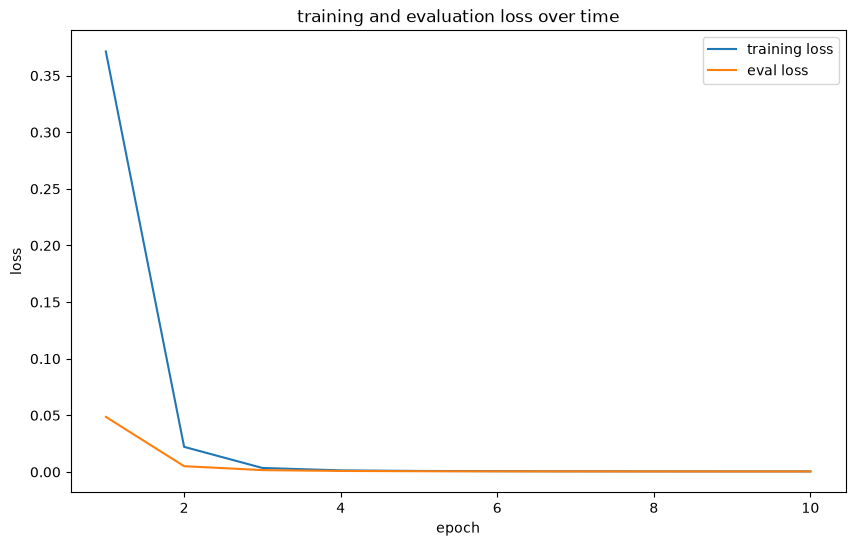

In [67]:
# plot the loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(trainer_history_trainer_df['epoch'], trainer_history_trainer_df['loss'], label='training loss')
plt.plot(trainer_history_eval_df['epoch'], trainer_history_eval_df['eval_loss'], label='eval loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and evaluation loss over time')
plt.legend()
plt.show()


In [69]:
# push the model to the huggingface hub
model_upload_url = trainer.push_to_hub(
    commit_message='uploading food not food text classifier model',
    token=HF_token
)
print("[INFO] model succesfully uploaded in the huggingface hub")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] model succesfully uploaded in the huggingface hub


In [70]:
# making and evaluating predictions on the test data 
predicitons_all = trainer.predict(tokenized_dataset['test'])
prediction_values = predicitons_all.predictions
prediction_metrics = predicitons_all.metrics

print(f"[INFO] prediction metrics on prediction data")
prediction_metrics


[INFO] prediction metrics on prediction data


{'test_loss': 0.0004073162854183465,
 'test_accuracy': 1.0,
 'test_runtime': 1.5055,
 'test_samples_per_second': 33.211,
 'test_steps_per_second': 1.328}

In [76]:
# predicted logits ---> prediction probability with softmax
import torch
from sklearn.metrics import accuracy_score

# 1. get prediction probability using torch.softmax
pred_probs = torch.softmax(torch.tensor(prediction_values), dim=0)
pred_probs_one = torch.softmax(torch.tensor(predicitons_all.predictions[0]), dim=0)

# 2. get predicted labels 
pred_labels = torch.argmax(pred_probs, dim=1)


# 3. get the true labels 
true_labels = tokenized_dataset['test']['label']

# 4. compute prediction labels to true labels and get the test accuracy 
test_accuracy = accuracy_score(y_true=true_labels,
                              y_pred=pred_labels)

print(f"test accuracy {test_accuracy*100}")

test accuracy 100.0


## Note

If you want a good evaluation method, make predictions on your entire test dataset, then index on the predictions which are wrong but have high prediction probability.

For example, get the top 100-1000 and go through all of the examples where the model's prediction had high probability but was incorrect. This often leads to great insights into your data.

In [77]:
# exploring our model prediction probailities 

# 1. make a data frame of test predictions 
test_prediction_df = pd.DataFrame({
    "text": tokenized_dataset['test']['text'],
    'true_label': true_labels,
    "pred_labels": pred_labels,
    "pred_probs": torch.max(pred_probs, dim=1).values
})

test_prediction_df.head()

,text,true_label,pred_labels,pred_probs
0,A slice of pepperoni pizza with a layer of mel...,1,1,0.030627
1,Red brick fireplace with a mantel serving as a...,0,0,0.058380
2,A bowl of sliced bell peppers with a sprinkle ...,1,1,0.030367
3,Set of mugs hanging on a hook,0,0,0.059464
4,Standing floor lamp providing light next to an...,0,0,0.058379


In [79]:
# show 10 examples with the lowest prediction probaility
test_prediction_df.sort_values('pred_probs', ascending=True).head(10)

,text,true_label,pred_labels,pred_probs
40,A bowl of cherries with a sprig of mint for ga...,1,1,0.027311
11,A close-up shot of a cheesy pizza slice being ...,1,1,0.027578
49,Plate of sushi served with pickled ginger and ...,1,1,0.029905
34,"Mouthwatering mushroom curry, featuring shiita...",1,1,0.030006
20,"Pizza with a seafood theme, featuring toppings...",1,1,0.030087
35,Luxurious coconut shrimp curry on a generous p...,1,1,0.030137
37,"Close-up of a sushi roll with avocado, cucumbe...",1,1,0.030162
46,A bowl of sliced kiwi with a sprinkle of sugar...,1,1,0.030189
9,Cherry tomatoes and mozzarella balls in a bowl...,1,1,0.030274
26,A fruit platter with a variety of exotic fruit...,1,1,0.030314


In [5]:
import torch
local_model_path = 'models/learn_hf_food_not_food_text_classifier_distilbert'

huggingface_model_path = 'mahdiiaazad/learn_hf_food_not_food_text_classifier_distilbert'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [45]:
from transformers import pipeline

# se thte batch size
BATCH_SIZE = 32
# create an instance of transformers pipeline 
food_not_foor_clasifier = pipeline(task='text-classification',
                                  model=local_model_path,
                                  device=device,
                                  top_k=1,
                                  batch_size = BATCH_SIZE)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [67]:
test_sentence = 'pizza is my favorit fod'
result = food_not_foor_clasifier(test_sentence)

In [68]:
result

[[{'label': 'not_food', 'score': 0.9958181977272034}]]

In [71]:
# delete our pipeline to experiment with a nother model
del food_not_foor_clasifier

In [72]:
# use pipeline with a model from hugging face 
from transformers import pipeline
food_not_food_classifier = pipeline(
    task='text-classification',
    model=huggingface_model_path,
    device=device,
    top_k=1,
    batch_size = BATCH_SIZE)


config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

D:\HuggingFace_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\huggingface-cache\hub\models--mahdiiaazad--learn_hf_food_not_food_text_classifier_distilbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
D:\HuggingFace_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWa

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

In [76]:
test_sentence = 'pizza is good italian meal'

result = food_not_food_classifier(test_sentence)

In [77]:
result 

[[{'label': 'food', 'score': 0.9993577599525452}]]

In [78]:
# Create a list of sentences to make predictions on
sentences = [
    "I whipped up a fresh batch of code, but it seems to have a syntax error.",
    "We need to marinate these ideas overnight before presenting them to the client.",
    "The new software is definitely a spicy upgrade, taking some time to get used to.",
    "Her social media post was the perfect recipe for a viral sensation.",
    "He served up a rebuttal full of facts, leaving his opponent speechless.",
    "The team needs to simmer down a bit before tackling the next challenge.",
    "The presentation was a delicious blend of humor and information, keeping the audience engaged.",
    "A beautiful array of fake wax foods (shokuhin sampuru) in the front of a Japanese restaurant.",
    "Daniel Bourke is really cool :D",
    "My favourite food is biltong!"
]
food_not_food_classifier(sentences)

[[{'label': 'not_food', 'score': 0.9980687499046326}],
 [{'label': 'not_food', 'score': 0.997379720211029}],
 [{'label': 'not_food', 'score': 0.9979504942893982}],
 [{'label': 'not_food', 'score': 0.9990569949150085}],
 [{'label': 'not_food', 'score': 0.9976508021354675}],
 [{'label': 'not_food', 'score': 0.9986611604690552}],
 [{'label': 'not_food', 'score': 0.9946883916854858}],
 [{'label': 'food', 'score': 0.9991944432258606}],
 [{'label': 'not_food', 'score': 0.9995549321174622}],
 [{'label': 'not_food', 'score': 0.9870757460594177}]]

# making predictions with pytorch 

step with pytorch prediction:
1. create tokenizer with `Autotkenizer`
2. create the model with AutoModel (`AutoModelForSequenceClassification`)
3. tokenized text with 1
4. make prediction with 2
5. format prediction

In [6]:
from transformers import AutoTokenizer

# setup the model path 
model_path = local_model_path

# create an example to predict on
sample_food_text = 'a delicious photo of a palte of scrabled eggs'

# prepare the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=model_path,
)
inputs = tokenizer(sample_food_text,
                  return_tensors='pt') # 'pt' stands for pytorch

In [11]:
from transformers import AutoModelForSequenceClassification

# load out text classification model
model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path=model_path,
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [13]:
import torch

model.eval()

with torch.inference_mode():
    outputs = model(**inputs)

    outputs_verbose = model(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask']
    )

outputs

SequenceClassifierOutput(loss=None, logits=tensor([[ 2.8063, -3.2568]]), hidden_states=None, attentions=None)

In [16]:
# convert logits to prediction probability + label
predicted_class_id = outputs.logits.argmax().item()
prediction_probability = torch.softmax(outputs.logits, dim=1).max().item()

In [19]:
print(f'prediction scores: {prediction_probability}')
print(f"prodicted label: {model.config.id2label[predicted_class_id]}")

prediction scores: 0.9976783394813538
prodicted label: not_food


In [20]:
import gradio as gr

# putting everything together 

In [4]:
# 1. Import necessary packages
import pprint
from pathlib import Path

import numpy as np 
import pandas as pd 
import torch

import datasets
import evaluate

from transformers import pipeline 
from transformers import TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# 2. Setup variables for model training and saving pipeline
DATASET_NAME = 'mrdbourke/learn_hf_food_not_food_image_captions'
MODEL_NAME = 'distilbert/distilbert-base-uncased'
MODEL_SAVE_DIR_NAME = 'models/learn_hf_food_not_food_text_classifier_distilbert'

# 3. Create a directory for saving models
print(f'[INFO] creating directory for saving models {MODEL_SAVE_DIR_NAME}')
model_save_dir = Path(MODEL_SAVE_DIR_NAME)
model_save_dir.mkdir(parents=True, exist_ok=True)

# 4. Load and preprocess the dataset from Hugging Face Hub
print(f'[INFO] downloading dataset from huggingface_hub, name:{DATASET_NAME}')
dataset = datasets.load_dataset(DATASET_NAME)

id2label = {idx:label for idx, label in enumerate(dataset['train'].unique('label')[::-1])}
label2id = {label:idx for idx, label in id2label.items()}

# create a fucntion to map ids to labels
def map_labels_to_number(example):
    example["label"] = label2id[example["label"]]
    return example

# map our prerocessing function to our dataset 
dataset = dataset['train'].map(map_labels_to_number)

# split the dataset into train/test set
dataset = dataset.train_test_split(test_size=0.2)
dataset

# 5. Import a tokenizer and map it to our dataset
print(f'[INFO] tokenizign text for model training with tokenizer{MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME,
                                          use_fast=True)

# create function to tokenize our text sample
def tokenize(example):
    return tokenizer(example['text'], truncation=True, padding=True)

tokenized_dataset = dataset.map(tokenize, batched=True, batch_size=1000)
tokenized_dataset


# 6. Set up an evaluation metric
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(predictions_and_labels):
    predictions, labels = predictions_and_labels 

    # model willlogits in the form ([item_n, item_n], [item_m, item_m]) depending on number of classes that you have 
    # but we want to compaire labels which are in the format ([0,0,0,0,1]) 
    if len(predictions.shape) >= 2:
      predictions = np.argmax(predictions, axis=-1)
    
    return accuracy_metric.compute(predictions=predictions, references=labels)

# 7. Set up a model
print(f'[INFO] loading model -> name: {MODEL_NAME}')
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                            num_labels=len(id2label),
                                                            id2label=id2label,
                                                            label2id=label2id)
print(f'[INFO] model loading complete')

training_args = TrainingArguments(
    output_dir=MODEL_SAVE_DIR_NAME,

    learning_rate=0.0001,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    num_train_epochs=10,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    save_total_limit=3,

    use_cpu=False,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    report_to="none",
    push_to_hub=False,
)
# predictions_and_labels would be the output of our model
def compute_accuracy(predictions_and_labels):
    """
    Computes the accuracy of the model by comparing
    the predicted class labels with the true labels.
    """

    predictions, labels = predictions_and_labels

    # Convert logits into predicted class IDs
    predictions = predictions.argmax(axis=-1)

    return accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

# create trainer instance 
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_accuracy,
)



# 8. Train the model
print(f'[INFO] training model')
results = trainer.train()
print(f'[INFO] training complete')

# 9. Save the train model (to a local directory)
print(f'[INFO] model training is complete')
print(f'[INFO] saving model to {MODEL_SAVE_DIR_NAME}')
trainer.save_model(MODEL_SAVE_DIR_NAME)
print(f'[INFO] model saved to {MODEL_SAVE_DIR_NAME}')

# 10. Push the model the Hugging Face Hub
print('[INFO] uploading the mode to the hugging face hub')
model_upload_url = trainer.push_to_hub(
    commit_message='Training complete'
)
print(f'[INFO] model uploaded to {model_upload_url}')

# 11. Evaluate the model on the test data
preditions_all = trainer.predict(tokenized_dataset['test'])
predition_values = preditions_all.predictions
prediction_metrics = preditions_all.metrics
print(f'[INFO] prediction metrics: {prediction_metrics}')

pprint.pprint(prediction_metrics)

[INFO] creating directory for saving models models/learn_hf_food_not_food_text_classifier_distilbert
[INFO] downloading dataset from huggingface_hub, name:mrdbourke/learn_hf_food_not_food_image_captions


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

[INFO] tokenizign text for model training with tokenizerdistilbert/distilbert-base-uncased


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

...

[INFO] model saved to models/learn_hf_food_not_food_text_classifier_distilbert
[INFO] uploading the mode to the hugging face hub


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] model uploaded to https://huggingface.co/mahdiiaazad/learn_hf_food_not_food_text_classifier_distilbert/commit/9f49cb144e3ca33b04758ee88cdf8cfa3cef9d06


D:\HuggingFace_project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[INFO] prediction metrics: {'test_loss': 0.1630392074584961, 'test_accuracy': 1.0, 'test_runtime': 2.9594, 'test_samples_per_second': 16.895, 'test_steps_per_second': 0.676}
{'test_accuracy': 1.0,
 'test_loss': 0.1630392074584961,
 'test_runtime': 2.9594,
 'test_samples_per_second': 16.895,
 'test_steps_per_second': 0.676}


In [29]:
from transformers import pipeline 
import torch
BATCH_SIZE = 32
device = 'cuda' if torch.cuda.is_available() else 'cpu'

food_not_food_classifier = pipeline(
    task='text-classification',
    model="models/learn_hf_food_not_food_text_classifier_distilbert",
    device=device,
    top_k=1,
    batch_size = BATCH_SIZE)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [5]:
import gradio as gr

In [30]:
def food_not_food_classifier_fn(text):
    return food_not_food_classifier(text)

In [31]:
food_not_food_classifier('i had pizza for dinner')

[[{'label': 'not_food', 'score': 0.6338347792625427}]]

In [32]:
interface = gr.Interface(fn=food_not_food_classifier_fn, 
                         inputs=gr.Textbox(lines=5, placeholder='inter your text here ....'), 
                         outputs= gr.Textbox(lines=5))

In [33]:
interface.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
